In [42]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Cargamos el archivo usando la tercera fila como encabezado

Leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv", header=2)

In [44]:
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [ ]:
# Eliminamos espacios sobrantes de los nombres de las columnas

Leads.columns = Leads.columns.str.strip()


# Eliminamos las columnas llamadas unnamed

Leads = Leads.loc[:, ~Leads.columns.str.contains("Unnamed")]


# Mostramos los nombres de las columnas

Leads.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [46]:
# Eliminamos espacios de la columna mes

Leads["Mes"] = Leads["Mes"].astype(str).str.strip()


# Convertimos año a numérico y completamos los años faltantes

Leads["Año"] = pd.to_numeric(Leads["Año"], errors="coerce").ffill()

In [47]:
# Lista de meses válidos

meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]


# Filtramos solamente los registros mensuales

Leads = Leads[Leads["Mes"].isin(meses)]

In [48]:
# Variables que vamos a categorizar

variables = ["Total", "Ilocalizable", "No Contesta", "D. Incorrectos", "Duplicados", "Efectivos", "Abiertos", "Ventas", "Conversion", "Efectividad de Leads"]

In [49]:
# Convertimos las variables a valores numéricos

for columna in variables:
    Leads[columna] = Leads[columna].astype(str)
    Leads[columna] = Leads[columna].str.replace(",", "")
    Leads[columna] = Leads[columna].str.replace("%", "")
    Leads[columna] = pd.to_numeric(Leads[columna], errors="coerce")

In [50]:
# Eliminamos los registros que tengan nulos en las variables

Leads = Leads.dropna(subset=variables)


# Reiniciamos el índice

Leads = Leads.reset_index(drop=True)

In [51]:
# Revisamos las dimensiones finales

print("Dimensiones:", Leads.shape)


# Revisamos los valores nulos

Leads[variables].isnull().sum()

Dimensiones: (28, 12)


Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [ ]:
# Número de observaciones

n = len(Leads)

print("Número de observaciones:", n)

Número de observaciones: 28


In [ ]:
# Valor máximo y mínimo de Total

Max_Total = Leads["Total"].max()
Min_Total = Leads["Total"].min()

Limites_Total = [Min_Total, Max_Total]
Limites_Total

[np.float64(178.0), np.float64(1973.0)]

In [ ]:
# Rango de Total

R_Total = Max_Total - Min_Total
R_Total

np.float64(1795.0)

In [55]:
# Regla de sturges

ni = 1 + 3.32 * np.log10(n)

print("Número de intervalos sin redondear:", ni)

Número de intervalos sin redondear: 5.8045646640561674


In [ ]:
# Número de intervalos

numero_intervalos = round(ni)
numero_intervalos

6

In [ ]:
# Ancho de cada intervalo

i_Total = R_Total / numero_intervalos
i_Total

np.float64(299.1666666666667)

In [ ]:
# Intervalos para la variable Total

intervalos_Total = np.linspace(177, 1974, 7)
intervalos_Total

array([ 177. ,  476.5,  776. , 1075.5, 1375. , 1674.5, 1974. ])

In [ ]:
# Nombres de categorías

categorias_Total = ["Categoría 1 (177-476.5)", "Categoría 2 (476.5-776)",
                    "Categoría 3 (776-1075.5)", "Categoría 4 (1075.5-1375)",
                    "Categoría 5 (1375-1674.5)","Categoría 6 (1674.5-1974)"]

In [ ]:
# Categorizar variable Total

Leads["Total"] = pd.cut(x=Leads["Total"], bins=intervalos_Total,labels=categorias_Total)

Leads["Total"]

0       Categoría 2 (476.5-776)
1       Categoría 1 (177-476.5)
2       Categoría 1 (177-476.5)
3       Categoría 1 (177-476.5)
4      Categoría 3 (776-1075.5)
5      Categoría 3 (776-1075.5)
6     Categoría 5 (1375-1674.5)
7     Categoría 4 (1075.5-1375)
8     Categoría 6 (1674.5-1974)
9     Categoría 5 (1375-1674.5)
10    Categoría 4 (1075.5-1375)
11     Categoría 3 (776-1075.5)
12      Categoría 2 (476.5-776)
13     Categoría 3 (776-1075.5)
14    Categoría 4 (1075.5-1375)
15     Categoría 3 (776-1075.5)
16    Categoría 4 (1075.5-1375)
17    Categoría 4 (1075.5-1375)
18    Categoría 5 (1375-1674.5)
19    Categoría 4 (1075.5-1375)
20    Categoría 4 (1075.5-1375)
21     Categoría 3 (776-1075.5)
22    Categoría 5 (1375-1674.5)
23    Categoría 5 (1375-1674.5)
24    Categoría 4 (1075.5-1375)
25    Categoría 6 (1674.5-1974)
26    Categoría 5 (1375-1674.5)
27    Categoría 4 (1075.5-1375)
Name: Total, dtype: category
Categories (6, str): ['Categoría 1 (177-476.5)' < 'Categoría 2 (476.5-776)'

In [ ]:
# Frecuencia de las categorías

Tabla_Total = Leads["Total"].value_counts().reset_index()
Tabla_Total

,Total,count
0,Categoría 4 (1075.5-1375),9
1,Categoría 3 (776-1075.5),6
2,Categoría 5 (1375-1674.5),6
3,Categoría 1 (177-476.5),3
4,Categoría 2 (476.5-776),2
5,Categoría 6 (1674.5-1974),2


In [ ]:
# Categorías con frecuencia mayor a cero

Filtro_Total = Tabla_Total[Tabla_Total["count"] > 0]
Filtro_Total

,Total,count
0,Categoría 4 (1075.5-1375),9
1,Categoría 3 (776-1075.5),6
2,Categoría 5 (1375-1674.5),6
3,Categoría 1 (177-476.5),3
4,Categoría 2 (476.5-776),2
5,Categoría 6 (1674.5-1974),2


In [ ]:
# Ajustamos índice 

Filtro_Total_index = Filtro_Total.set_index("Total")
Filtro_Total_index

,count
Total,
Categoría 4 (1075.5-1375),9
Categoría 3 (776-1075.5),6
Categoría 5 (1375-1674.5),6
Categoría 1 (177-476.5),3
Categoría 2 (476.5-776),2
Categoría 6 (1674.5-1974),2


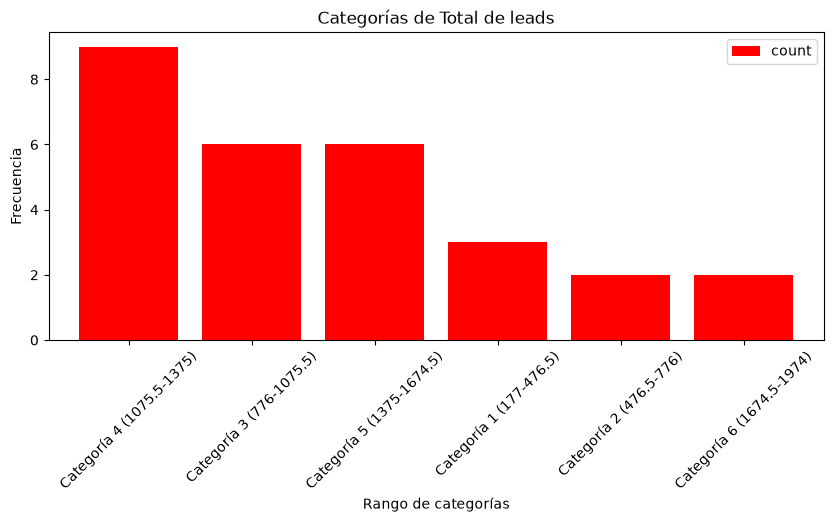

In [ ]:
# Gráfica de barras 1: Total

Filtro_Total_index.plot(kind="bar", width=0.8,figsize=(10,4),color="red", rot=45)

plt.title("Categorías de Total de leads")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Valor máximo y mínimo de Ilocalizable

Max_Ilocalizable = Leads["Ilocalizable"].max()
Min_Ilocalizable = Leads["Ilocalizable"].min()

Limites_Ilocalizable = [Min_Ilocalizable, Max_Ilocalizable]
Limites_Ilocalizable

[np.float64(5.0), np.float64(514.0)]

In [68]:
# Rango de Ilocalizable

R_Ilocalizable = Max_Ilocalizable - Min_Ilocalizable
R_Ilocalizable

np.float64(509.0)

In [69]:
# Ancho de cada intervalo

i_Ilocalizable = R_Ilocalizable / numero_intervalos
i_Ilocalizable

np.float64(84.83333333333333)

In [70]:
# Intervalos para Ilocalizable

intervalos_Ilocalizable = np.linspace(4, 515, 7)
intervalos_Ilocalizable

array([  4.        ,  89.16666667, 174.33333333, 259.5       ,
       344.66666667, 429.83333333, 515.        ])

In [71]:
# Categorías con sus rangos

categorias_Ilocalizable = ["Categoría 1 (4-89.17)", "Categoría 2 (89.17-174.33)",
                           "Categoría 3 (174.33-259.50)", "Categoría 4 (259.50-344.67)",
                           "Categoría 5 (344.67-429.83)", "Categoría 6 (429.83-515)"]

In [73]:
# Categorizar variable Ilocalizable

Leads["Categoria Ilocalizable"] = pd.cut(
    x=Leads["Ilocalizable"],
    bins=intervalos_Ilocalizable,
    labels=categorias_Ilocalizable
)

Leads[["Ilocalizable", "Categoria Ilocalizable"]].head()

,Ilocalizable,Categoria Ilocalizable
0,108.0,Categoría 2 (89.17-174.33)
1,37.0,Categoría 1 (4-89.17)
2,79.0,Categoría 1 (4-89.17)
3,33.0,Categoría 1 (4-89.17)
4,140.0,Categoría 2 (89.17-174.33)


In [74]:
# Frecuencia de las categorías

Tabla_Ilocalizable = Leads["Categoria Ilocalizable"].value_counts().reset_index()

Tabla_Ilocalizable

,Categoria Ilocalizable,count
0,Categoría 1 (4-89.17),13
1,Categoría 2 (89.17-174.33),9
2,Categoría 6 (429.83-515),3
3,Categoría 3 (174.33-259.50),2
4,Categoría 5 (344.67-429.83),1
5,Categoría 4 (259.50-344.67),0


In [75]:
# Categorías con frecuencia mayor a cero

Filtro_Ilocalizable = Tabla_Ilocalizable[Tabla_Ilocalizable["count"] > 0]

Filtro_Ilocalizable

,Categoria Ilocalizable,count
0,Categoría 1 (4-89.17),13
1,Categoría 2 (89.17-174.33),9
2,Categoría 6 (429.83-515),3
3,Categoría 3 (174.33-259.50),2
4,Categoría 5 (344.67-429.83),1


In [76]:
# Ajustamos índice 

Filtro_Ilocalizable_index = Filtro_Ilocalizable.set_index("Categoria Ilocalizable")

Filtro_Ilocalizable_index

,count
Categoria Ilocalizable,
Categoría 1 (4-89.17),13
Categoría 2 (89.17-174.33),9
Categoría 6 (429.83-515),3
Categoría 3 (174.33-259.50),2
Categoría 5 (344.67-429.83),1


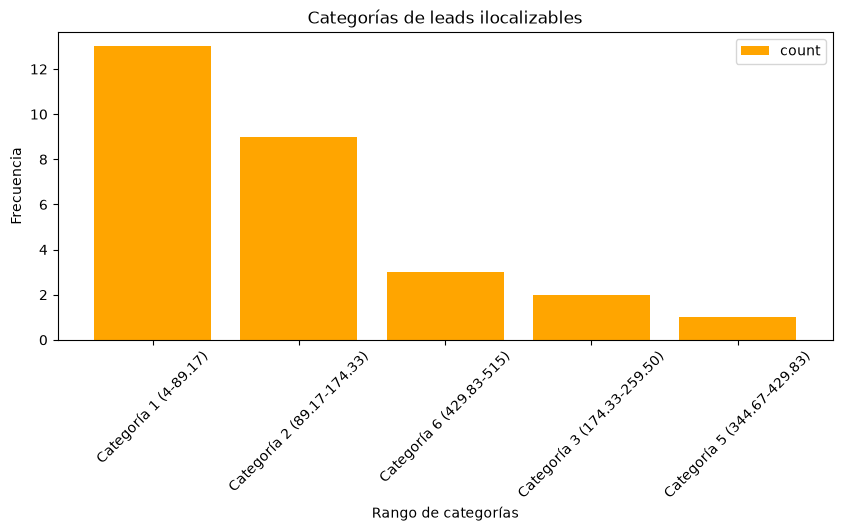

In [ ]:
# Gráfica de barras 2: Ilocalizables

Filtro_Ilocalizable_index.plot(kind="bar", width=0.8, figsize=(10,4), color="orange", rot=45)

plt.title("Categorías de leads ilocalizables")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [78]:
# Máximo, mínimo, rango y amplitud de No Contesta

Max_NoContesta = Leads["No Contesta"].max()
Min_NoContesta = Leads["No Contesta"].min()
R_NoContesta = Max_NoContesta - Min_NoContesta
i_NoContesta = R_NoContesta / numero_intervalos

print("Límites:", [Min_NoContesta, Max_NoContesta])
print("Rango:", R_NoContesta)
print("Amplitud:", i_NoContesta)

Límites: [np.float64(13.0), np.float64(606.0)]
Rango: 593.0
Amplitud: 98.83333333333333


In [79]:
# Intervalos y categorías

intervalos_NoContesta = np.linspace(12, 607, 7)

categorias_NoContesta = ["Categoría 1 (12-111.17)", "Categoría 2 (111.17-210.33)",
                         "Categoría 3 (210.33-309.50)", "Categoría 4 (309.50-408.67)",
                         "Categoría 5 (408.67-507.83)", "Categoría 6 (507.83-607)"]

In [80]:
# Categorizar variable

Leads["Categoria No Contesta"] = pd.cut(x=Leads["No Contesta"],bins=intervalos_NoContesta,labels=categorias_NoContesta)

In [81]:
# Tabla, filtro e índice

Tabla_NoContesta = Leads["Categoria No Contesta"].value_counts().reset_index()
Filtro_NoContesta = Tabla_NoContesta[Tabla_NoContesta["count"] > 0]
Filtro_NoContesta_index = Filtro_NoContesta.set_index("Categoria No Contesta")

Filtro_NoContesta

,Categoria No Contesta,count
0,Categoría 1 (12-111.17),9
1,Categoría 2 (111.17-210.33),8
2,Categoría 3 (210.33-309.50),4
3,Categoría 4 (309.50-408.67),4
4,Categoría 6 (507.83-607),2
5,Categoría 5 (408.67-507.83),1


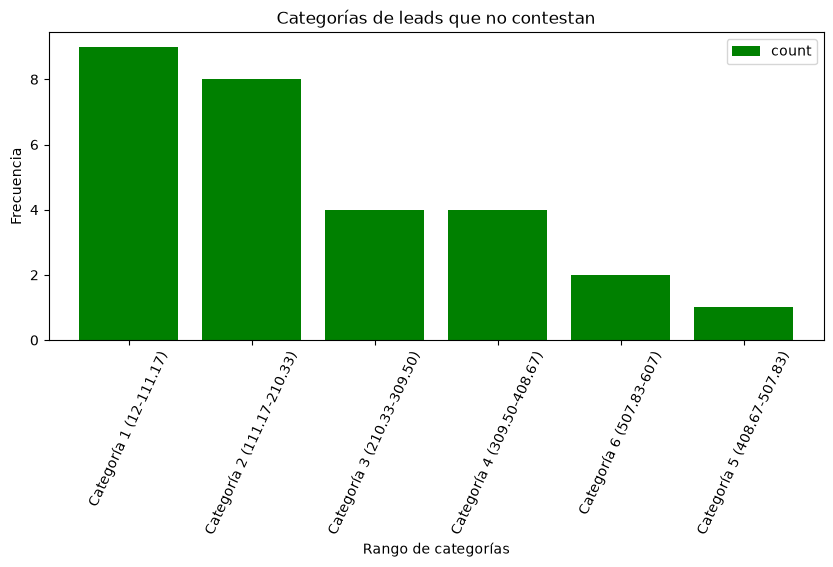

In [ ]:
# Gráfica de barras 3: No Contesta

Filtro_NoContesta_index.plot(kind="bar", width=0.8, figsize=(10,4),color="green", rot=65)

plt.title("Categorías de leads que no contestan")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [86]:
# Máximo, mínimo, rango y amplitud de D. Incorrectos

Max_Incorrectos = Leads["D. Incorrectos"].max()
Min_Incorrectos = Leads["D. Incorrectos"].min()
R_Incorrectos = Max_Incorrectos - Min_Incorrectos
i_Incorrectos = R_Incorrectos / numero_intervalos

print("Límites:", [Min_Incorrectos, Max_Incorrectos])
print("Rango:", R_Incorrectos)
print("Amplitud:", i_Incorrectos)

Límites: [np.float64(0.0), np.float64(62.0)]
Rango: 62.0
Amplitud: 10.333333333333334


In [87]:
# Intervalos y categorías

intervalos_Incorrectos = np.linspace(-1, 63, 7)

categorias_Incorrectos = ["Categoría 1 (-1-9.67)", "Categoría 2 (9.67-20.33)",
                          "Categoría 3 (20.33-31)", "Categoría 4 (31-41.67)",
                          "Categoría 5 (41.67-52.33)", "Categoría 6 (52.33-63)"]

In [88]:
# Categorizar variable

Leads["Categoria D. Incorrectos"] = pd.cut(x=Leads["D. Incorrectos"], bins=intervalos_Incorrectos,labels=categorias_Incorrectos)

In [89]:
# Tabla, filtro e índice

Tabla_Incorrectos = Leads["Categoria D. Incorrectos"].value_counts().reset_index()
Filtro_Incorrectos = Tabla_Incorrectos[Tabla_Incorrectos["count"] > 0]
Filtro_Incorrectos_index = Filtro_Incorrectos.set_index("Categoria D. Incorrectos")

Filtro_Incorrectos

,Categoria D. Incorrectos,count
0,Categoría 1 (-1-9.67),13
1,Categoría 2 (9.67-20.33),6
2,Categoría 5 (41.67-52.33),3
3,Categoría 3 (20.33-31),2
4,Categoría 4 (31-41.67),2
5,Categoría 6 (52.33-63),2


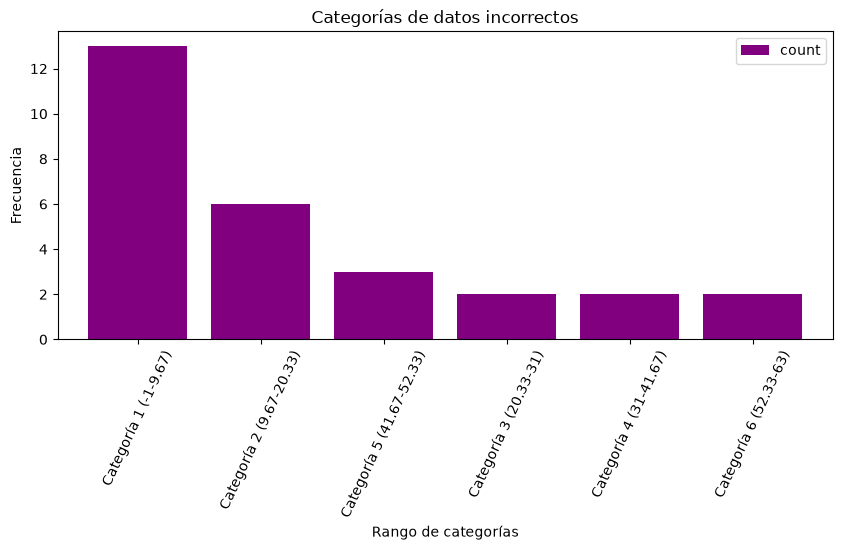

In [ ]:
# Gráfica de barras 4: D. Incorrectos

Filtro_Incorrectos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="purple", rot=65)

plt.title("Categorías de datos incorrectos")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [92]:
# Máximo, mínimo, rango y amplitud de Duplicados

Max_Duplicados = Leads["Duplicados"].max()
Min_Duplicados = Leads["Duplicados"].min()
R_Duplicados = Max_Duplicados - Min_Duplicados
i_Duplicados = R_Duplicados / numero_intervalos

print("Límites:", [Min_Duplicados, Max_Duplicados])
print("Rango:", R_Duplicados)
print("Amplitud:", i_Duplicados)

Límites: [np.float64(0.0), np.float64(136.0)]
Rango: 136.0
Amplitud: 22.666666666666668


In [93]:
# Intervalos y categorías

intervalos_Duplicados = np.linspace(-1, 137, 7)

categorias_Duplicados = ["Categoría 1 (-1-22)", "Categoría 2 (22-45)",
                         "Categoría 3 (45-68)", "Categoría 4 (68-91)",
                         "Categoría 5 (91-114)", "Categoría 6 (114-137)"]

In [94]:
# Categorizar variable

Leads["Categoria Duplicados"] = pd.cut(x=Leads["Duplicados"], bins=intervalos_Duplicados,labels=categorias_Duplicados)

In [95]:
# Tabla, filtro e índice

Tabla_Duplicados = Leads["Categoria Duplicados"].value_counts().reset_index()
Filtro_Duplicados = Tabla_Duplicados[Tabla_Duplicados["count"] > 0]
Filtro_Duplicados_index = Filtro_Duplicados.set_index("Categoria Duplicados")

Filtro_Duplicados

,Categoria Duplicados,count
0,Categoría 1 (-1-22),13
1,Categoría 2 (22-45),6
2,Categoría 3 (45-68),6
3,Categoría 4 (68-91),1
4,Categoría 5 (91-114),1
5,Categoría 6 (114-137),1


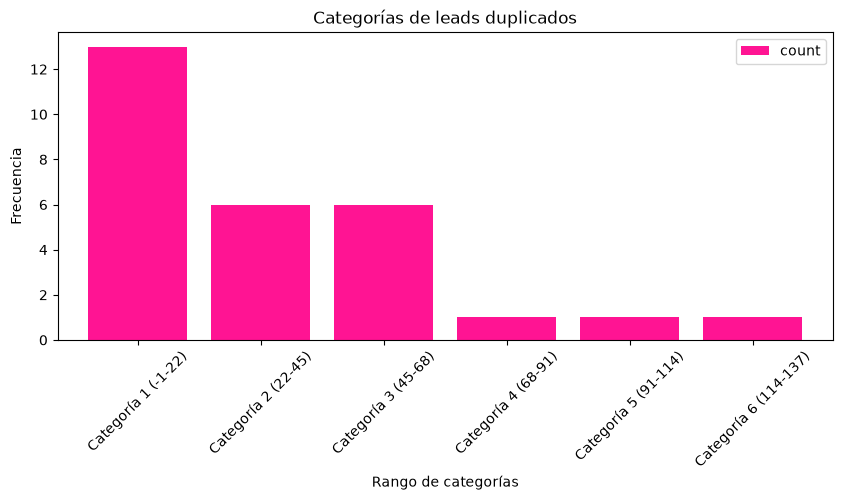

In [ ]:
# Gráfica de barras 5: Duplicados

Filtro_Duplicados_index.plot(kind="bar", width=0.8, figsize=(10,4),color="deeppink", rot=45)

plt.title("Categorías de leads duplicados")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [97]:
# Máximo, mínimo, rango y amplitud de Efectivos

Max_Efectivos = Leads["Efectivos"].max()
Min_Efectivos = Leads["Efectivos"].min()
R_Efectivos = Max_Efectivos - Min_Efectivos
i_Efectivos = R_Efectivos / numero_intervalos

print("Límites:", [Min_Efectivos, Max_Efectivos])
print("Rango:", R_Efectivos)
print("Amplitud:", i_Efectivos)

Límites: [np.float64(128.0), np.float64(1040.0)]
Rango: 912.0
Amplitud: 152.0


In [98]:
# Intervalos y categorías

intervalos_Efectivos = np.linspace(127, 1041, 7)

categorias_Efectivos = ["Categoría 1 (127-279.33)", "Categoría 2 (279.33-431.67)",
                        "Categoría 3 (431.67-584)", "Categoría 4 (584-736.33)",
                        "Categoría 5 (736.33-888.67)", "Categoría 6 (888.67-1041)"]

In [ ]:
# Categorizar variable

Leads["Categoria Efectivos"] = pd.cut(x=Leads["Efectivos"],bins=intervalos_Efectivos,labels=categorias_Efectivos)

In [100]:
# Tabla, filtro e índice

Tabla_Efectivos = Leads["Categoria Efectivos"].value_counts().reset_index()
Filtro_Efectivos = Tabla_Efectivos[Tabla_Efectivos["count"] > 0]
Filtro_Efectivos_index = Filtro_Efectivos.set_index("Categoria Efectivos")

Filtro_Efectivos

,Categoria Efectivos,count
0,Categoría 4 (584-736.33),12
1,Categoría 3 (431.67-584),5
2,Categoría 6 (888.67-1041),4
3,Categoría 5 (736.33-888.67),3
4,Categoría 1 (127-279.33),2
5,Categoría 2 (279.33-431.67),2


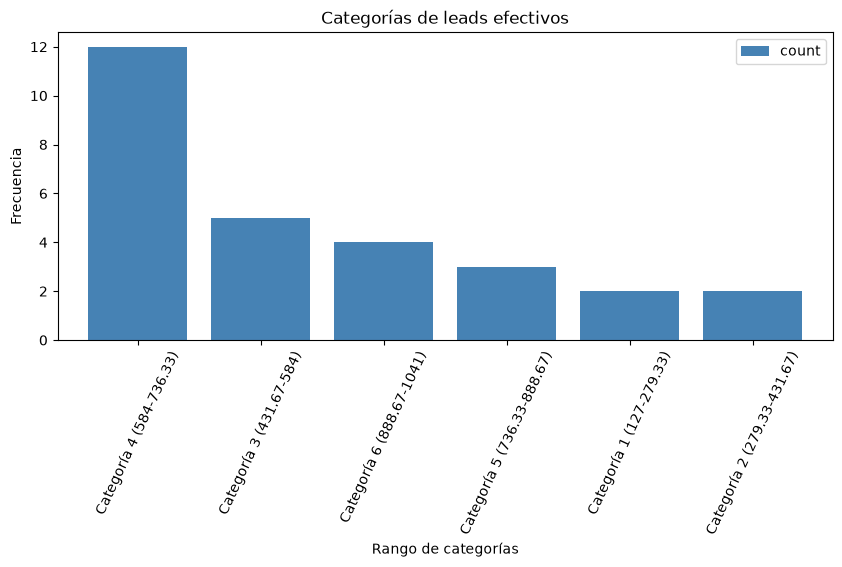

In [ ]:
# Gráfica de barras 6: Efectivos

Filtro_Efectivos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="steelblue", rot=65)

plt.title("Categorías de leads efectivos")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [103]:
# Máximo, mínimo, rango y amplitud de Abiertos

Max_Abiertos = Leads["Abiertos"].max()
Min_Abiertos = Leads["Abiertos"].min()
R_Abiertos = Max_Abiertos - Min_Abiertos
i_Abiertos = R_Abiertos / numero_intervalos

print("Límites:", [Min_Abiertos, Max_Abiertos])
print("Rango:", R_Abiertos)
print("Amplitud:", i_Abiertos)

Límites: [np.float64(1.0), np.float64(823.0)]
Rango: 822.0
Amplitud: 137.0


In [104]:
# Intervalos y categorías

intervalos_Abiertos = np.linspace(0, 824, 7)

categorias_Abiertos = ["Categoría 1 (0-137.33)", "Categoría 2 (137.33-274.67)",
                       "Categoría 3 (274.67-412)", "Categoría 4 (412-549.33)",
                       "Categoría 5 (549.33-686.67)","Categoría 6 (686.67-824)"]

In [ ]:
# Categorizar variable

Leads["Categoria Abiertos"] = pd.cut(x=Leads["Abiertos"], bins=intervalos_Abiertos,labels=categorias_Abiertos)

In [106]:
# Tabla, filtro e índice

Tabla_Abiertos = Leads["Categoria Abiertos"].value_counts().reset_index()
Filtro_Abiertos = Tabla_Abiertos[Tabla_Abiertos["count"] > 0]
Filtro_Abiertos_index = Filtro_Abiertos.set_index("Categoria Abiertos")

Filtro_Abiertos

,Categoria Abiertos,count
0,Categoría 1 (0-137.33),11
1,Categoría 2 (137.33-274.67),5
2,Categoría 3 (274.67-412),5
3,Categoría 4 (412-549.33),3
4,Categoría 5 (549.33-686.67),2
5,Categoría 6 (686.67-824),2


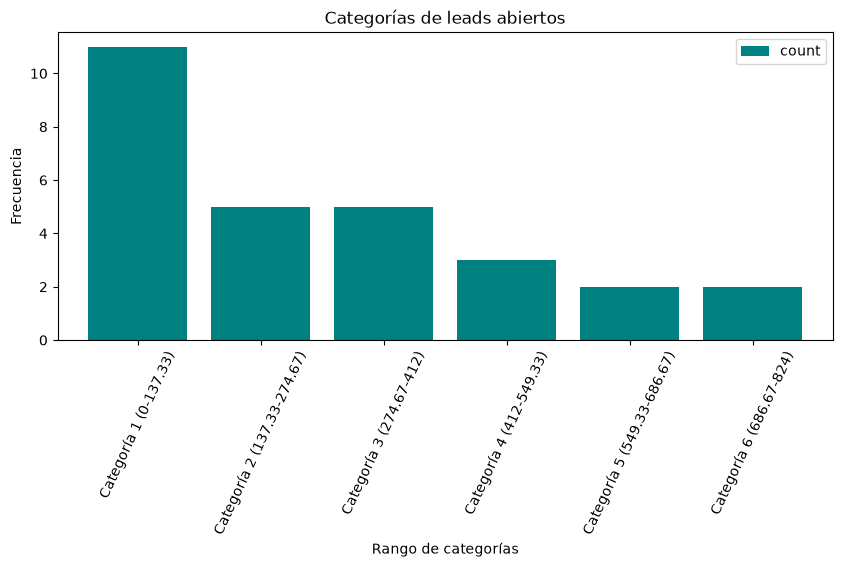

In [ ]:
# Gráfica de barras 7: Abiertos

Filtro_Abiertos_index.plot(kind="bar", width=0.8, figsize=(10,4),color="teal", rot=65)

plt.title("Categorías de leads abiertos")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [111]:
# Máximo, mínimo, rango y amplitud de Ventas

Max_Ventas = Leads["Ventas"].max()
Min_Ventas = Leads["Ventas"].min()
R_Ventas = Max_Ventas - Min_Ventas
i_Ventas = R_Ventas / numero_intervalos

print("Límites:", [Min_Ventas, Max_Ventas])
print("Rango:", R_Ventas)
print("Amplitud:", i_Ventas)

Límites: [np.float64(6.0), np.float64(41.0)]
Rango: 35.0
Amplitud: 5.833333333333333


In [112]:
# Intervalos y categorías

intervalos_Ventas = np.linspace(5, 42, 7)

categorias_Ventas = ["Categoría 1 (5-11.17)", "Categoría 2 (11.17-17.33)",
                     "Categoría 3 (17.33-23.50)", "Categoría 4 (23.50-29.67)",
                     "Categoría 5 (29.67-35.83)", "Categoría 6 (35.83-42)"]

In [113]:
# Categorizar variable

Leads["Categoria Ventas"] = pd.cut(x=Leads["Ventas"],bins=intervalos_Ventas,labels=categorias_Ventas)

In [114]:
# Tabla, filtro e índice

Tabla_Ventas = Leads["Categoria Ventas"].value_counts().reset_index()
Filtro_Ventas = Tabla_Ventas[Tabla_Ventas["count"] > 0]
Filtro_Ventas_index = Filtro_Ventas.set_index("Categoria Ventas")

Filtro_Ventas

,Categoria Ventas,count
0,Categoría 6 (35.83-42),8
1,Categoría 5 (29.67-35.83),7
2,Categoría 2 (11.17-17.33),4
3,Categoría 3 (17.33-23.50),4
4,Categoría 1 (5-11.17),3
5,Categoría 4 (23.50-29.67),2


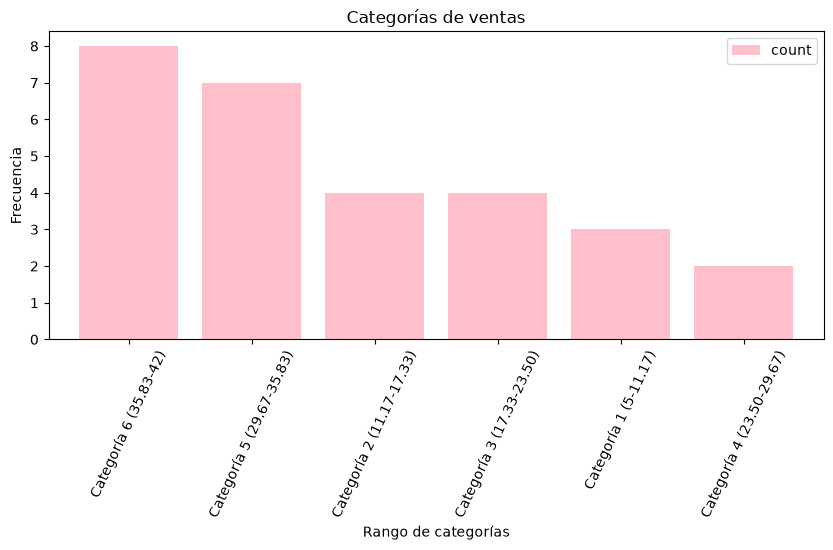

In [ ]:
# Gráfica de barras 8: Ventas

Filtro_Ventas_index.plot(kind="bar", width=0.8, figsize=(10,4),color="pink", rot=65)

plt.title("Categorías de ventas")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [118]:
# Máximo, mínimo, rango y amplitud de Conversion

Max_Conversion = Leads["Conversion"].max()
Min_Conversion = Leads["Conversion"].min()
R_Conversion = Max_Conversion - Min_Conversion
i_Conversion = R_Conversion / numero_intervalos

print("Límites:", [Min_Conversion, Max_Conversion])
print("Rango:", R_Conversion)
print("Amplitud:", i_Conversion)

Límites: [np.float64(1.0), np.float64(5.9)]
Rango: 4.9
Amplitud: 0.8166666666666668


In [119]:
# Intervalos y categorías

intervalos_Conversion = np.linspace(0.9, 6, 7)

categorias_Conversion = ["Categoría 1 (0.90%-1.75%)", "Categoría 2 (1.75%-2.60%)",
                         "Categoría 3 (2.60%-3.45%)", "Categoría 4 (3.45%-4.30%)",
                         "Categoría 5 (4.30%-5.15%)", "Categoría 6 (5.15%-6.00%)"]

In [120]:
# Categorizar variable

Leads["Categoria Conversion"] = pd.cut(x=Leads["Conversion"],bins=intervalos_Conversion,labels=categorias_Conversion)

In [121]:
# Tabla, filtro e índice

Tabla_Conversion = Leads["Categoria Conversion"].value_counts().reset_index()
Filtro_Conversion = Tabla_Conversion[Tabla_Conversion["count"] > 0]
Filtro_Conversion_index = Filtro_Conversion.set_index("Categoria Conversion")

Filtro_Conversion

,Categoria Conversion,count
0,Categoría 4 (3.45%-4.30%),8
1,Categoría 6 (5.15%-6.00%),8
2,Categoría 3 (2.60%-3.45%),7
3,Categoría 5 (4.30%-5.15%),3
4,Categoría 1 (0.90%-1.75%),1
5,Categoría 2 (1.75%-2.60%),1


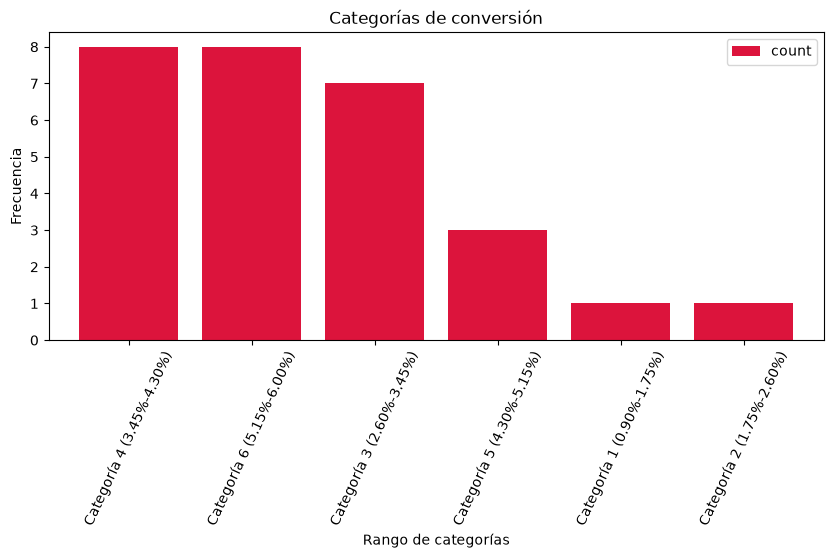

In [ ]:
# Gráfica de barras 9: Conversion

Filtro_Conversion_index.plot(kind="bar", width=0.8, figsize=(10,4),color="crimson", rot=65)

plt.title("Categorías de conversión")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()

In [125]:
# Máximo, mínimo, rango y amplitud de Efectividad de Leads

Max_Efectividad = Leads["Efectividad de Leads"].max()
Min_Efectividad = Leads["Efectividad de Leads"].min()
R_Efectividad = Max_Efectividad - Min_Efectividad
i_Efectividad = R_Efectividad / numero_intervalos

print("Límites:", [Min_Efectividad, Max_Efectividad])
print("Rango:", R_Efectividad)
print("Amplitud:", i_Efectividad)

Límites: [np.float64(39.0), np.float64(83.0)]
Rango: 44.0
Amplitud: 7.333333333333333


In [127]:
# Intervalos y categorías

intervalos_Efectividad = np.linspace(38, 84, 7)

categorias_Efectividad = ["Categoría 1 (38%-45.67%)", "Categoría 2 (45.67%-53.33%)",
                          "Categoría 3 (53.33%-61%)", "Categoría 4 (61%-68.67%)",
                          "Categoría 5 (68.67%-76.33%)", "Categoría 6 (76.33%-84%)"]

In [128]:
# Categorizar variable

Leads["Categoria Efectividad"] = pd.cut(x=Leads["Efectividad de Leads"], bins=intervalos_Efectividad, labels=categorias_Efectividad)

In [130]:
# Tabla, filtro e índice

Tabla_Efectividad = Leads["Categoria Efectividad"].value_counts().reset_index()
Filtro_Efectividad = Tabla_Efectividad[Tabla_Efectividad["count"] > 0]
Filtro_Efectividad_index = Filtro_Efectividad.set_index("Categoria Efectividad")

Filtro_Efectividad

,Categoria Efectividad,count
0,Categoría 5 (68.67%-76.33%),8
1,Categoría 2 (45.67%-53.33%),5
2,Categoría 3 (53.33%-61%),5
3,Categoría 4 (61%-68.67%),5
4,Categoría 1 (38%-45.67%),3
5,Categoría 6 (76.33%-84%),2


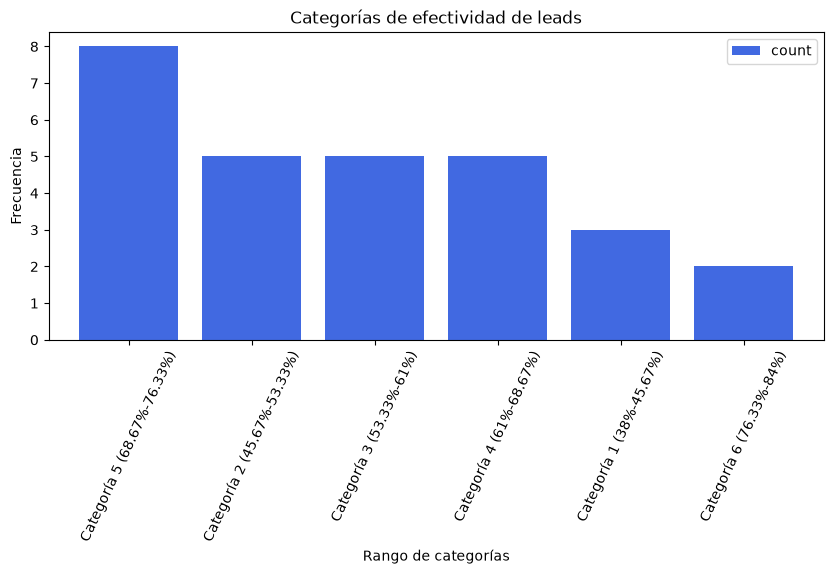

In [ ]:
# Gráfica de barras 10: Efectividad de Leads

Filtro_Efectividad_index.plot(kind="bar", width=0.8, figsize=(10,4),color="royalblue", rot=65)

plt.title("Categorías de efectividad de leads")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.show()